**Sujet 3 : Détection et Analyse du Phishing**

Ce notebook couvre :
1. Chargement du dataset manuel (lecture seule — jamais modifié)
2. Génération synthétique par templates
3. Fusion, nettoyage et augmentation sur dataset_final uniquement
4. Statistiques et visualisations

## Cellule 1 — Imports

In [1]:
import pandas as pd
import json
import random
import os
import copy
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(42)


## Cellule 2 — Chargement du Dataset Manuel 

In [2]:
DATASET_PATH = 'dataset/dataset_manuel.json'

with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    data_manuel_raw = json.load(f)  # ← données brutes, jamais modifiées

df_manuel = pd.DataFrame(data_manuel_raw)
print(f'Dataset manuel chargé : {len(df_manuel)} exemples')
print(f'\nAperçu :')
print(df_manuel.head(3))
print(df_manuel['label'].value_counts())
print('\nTotal :', len(df_manuel))


Dataset manuel chargé : 60 exemples

Aperçu :
                                                text     label   type  \
0  votre compte CIH a ete suspendu  clickez ici p...  phishing    SMS   
1  Attijari_wafa bank : veuillez confirmer vos in...  phishing  email   
2  your PayPal account needs verification.please ...  phishing  email   

            attack_type risk_level  language                               url  
0             bank scam       high  francais     https://www.cihbank-login.com  
1             bank scam       high  francais  https://www.Attijariwafa-bank.ma  
2  account verification     medium   english      https://www.amazon-login.com  
label
phishing        30
non_phishing    30
Name: count, dtype: int64

Total : 60


## Cellule 3 — Templates Phishing

In [4]:
phishing_templates_fr = [
    ('votre compte {bank} a été suspendu, cliquez ici pour le réactiver immédiatement',          'bank scam',             'high',   'sms'),
    ('alerte {bank} : transaction suspecte de {amount} MAD détectée, vérifiez maintenant',       'bank scam',             'high',   'sms'),
    ('{bank} : votre mot de passe expire dans 24h, renouvelez-le ici',                           'credential harvesting', 'high',   'email'),
    ('votre colis {shop} est bloqué à la douane, payez les frais de livraison',                  'delivery scam',         'medium', 'sms'),
    ('félicitations ! vous avez gagné un {prize}, cliquez pour réclamer votre récompense',       'lottery scam',          'high',   'social_media'),
    ('votre abonnement {telecom} sera suspendu ce soir si vous ne payez pas',                    'fake billing',          'high',   'sms'),
    ('{bank} : confirmez vos identifiants pour éviter la fermeture définitive de votre compte',  'credential harvesting', 'high',   'email'),
    ('votre compte {social} sera désactivé dans 24h, vérifiez votre identité maintenant',        'account suspension',    'medium', 'social_media'),
    ('{bank} : votre carte bancaire a été bloquée suite à une activité suspecte',                'bank scam',             'high',   'sms'),
    ('action requise : mettez à jour vos informations {bank} pour éviter toute interruption',    'credential harvesting', 'high',   'email'),
    ('votre remboursement de {amount} MAD est disponible, cliquez pour le récupérer',            'lottery scam',          'medium', 'email'),
    ('{shop} : votre commande est en attente de paiement, réglez-la immédiatement',              'fake billing',          'medium', 'email'),
    ('votre accès {social} a été compromis, sécurisez votre compte maintenant',                  'social media hack',     'high',   'social_media'),
    ('{telecom} : votre ligne sera coupée aujourd\'hui, rechargez maintenant',                   'urgent scam',           'high',   'sms'),
    ('alerte sécurité : connexion depuis un appareil inconnu sur votre compte {bank}',           'security alert',        'high',   'email'),
]

phishing_templates_en = [
    ('your {bank} account has been locked, verify now to restore access',                        'bank scam',             'high',   'email'),
    ('{shop}: your order is on hold due to payment issues, resolve now',                         'delivery scam',         'medium', 'email'),
    ('congratulations! you won a {prize}, enter your details to claim your reward',              'lottery scam',          'high',   'social_media'),
    ('your {social} account was accessed from an unknown device, secure it now',                 'social media hack',     'high',   'social_media'),
    ('{bank}: suspicious activity of {amount} USD detected, confirm your details now',           'bank scam',             'high',   'sms'),
    ('your {telecom} subscription will be cancelled unless you pay within 24 hours',             'fake billing',          'medium', 'email'),
    ('your {shop} package is held at customs, pay {amount} USD fees to release it',              'delivery scam',         'medium', 'sms'),
    ('your {bank} password has expired, reset it immediately to avoid losing access',            'credential harvesting', 'high',   'email'),
    ('urgent: your {bank} card has been suspended due to suspicious transaction',                'bank scam',             'high',   'sms'),
    ('your {social} account will be permanently deleted, verify your identity now',              'account suspension',    'medium', 'social_media'),
    ('security alert: someone tried to access your {bank} account from a new location',         'security alert',        'high',   'email'),
    ('{telecom}: your line will be deactivated today, recharge now to keep it active',           'urgent scam',           'high',   'sms'),
    ('click here to claim your {amount} USD refund from {shop}',                                'lottery scam',          'medium', 'email'),
    ('update your {bank} account information to avoid permanent suspension',                     'credential harvesting', 'high',   'email'),
]

phishing_templates_ar = [
    ('تم تعليق حسابكم في {bank}، يرجى التحقق فوراً لتجنب الإغلاق النهائي',                     'bank scam',             'high',   'sms'),
    ('{bank}: تم رصد نشاط مشبوه بقيمة {amount} درهم، قوموا بتأكيد بياناتكم',                  'bank scam',             'high',   'email'),
    ('تهانينا! فزتم بـ{prize}، اضغطوا هنا للمطالبة بجائزتكم الآن',                             'lottery scam',          'high',   'social_media'),
    ('حسابكم في {social} معرض للإغلاق الدائم، تحققوا من هويتكم الآن',                          'account suspension',    'medium', 'social_media'),
    ('{telecom}: خطكم سيتوقف اليوم، ادفعوا الفاتورة الآن لتجنب الانقطاع',                      'fake billing',          'high',   'sms'),
    ('بطاقتكم البنكية في {bank} تم إيقافها مؤقتاً بسبب نشاط غير عادي',                         'bank scam',             'high',   'sms'),
    ('يرجى تحديث بيانات حسابكم في {bank} فوراً لتجنب تعليق الخدمة',                            'credential harvesting', 'high',   'email'),
    ('طلبكم من {shop} معلق بسبب مشكلة في الدفع، تصرفوا الآن',                                  'delivery scam',         'medium', 'email'),
    ('تنبيه أمني: تم تسجيل الدخول إلى حسابكم {bank} من جهاز غير معروف',                       'security alert',        'high',   'email'),
    ('مبروك! تم اختياركم للحصول على {amount} درهم، اضغطوا هنا فوراً',                          'lottery scam',          'high',   'social_media'),
]

print('Templates phishing définis')
print(f'   FR : {len(phishing_templates_fr)} | EN : {len(phishing_templates_en)} | AR : {len(phishing_templates_ar)}')

Templates phishing définis
   FR : 15 | EN : 14 | AR : 10


## Cellule 4 — Templates Légitimes

In [5]:
non_phishing_templates_fr = [
    ('{bank} : votre virement de {amount} MAD a été effectué avec succès',            'sms',          'low'),
    ('{bank} : votre relevé mensuel est disponible dans votre espace client',         'email',        'low'),
    ('{telecom} : votre recharge de {amount} MAD a été créditée sur votre compte',   'sms',          'low'),
    ('{shop} : votre commande a été expédiée, livraison prévue dans 3 jours',         'email',        'low'),
    ('{telecom} : votre abonnement mensuel a été renouvelé automatiquement',          'email',        'low'),
    ('{shop} : votre colis a été livré avec succès à votre adresse',                  'sms',          'low'),
    ('{bank} : paiement de facture de {amount} MAD traité avec succès',               'sms',          'low'),
    ('{social} : votre publication a reçu {amount} mentions j\'aime',               'social_media', 'low'),
    ('bonjour, pouvez-vous m\'envoyer le rapport avant ce soir ?',                   'email',        'low'),
    ('rappel : réunion d\'équipe demain à 9h, salle de conférence B',                'email',        'low'),
    ('{bank} : votre demande de crédit a été approuvée avec succès',                  'email',        'low'),
    ('votre rendez-vous médical est confirmé pour demain à 14h30',                    'sms',          'low'),
    ('{shop} : votre retour a été approuvé, remboursement sous 5 jours',              'email',        'low'),
    ('votre note de frais a été validée et sera remboursée cette semaine',            'email',        'low'),
    ('{bank} : opération de {amount} MAD effectuée depuis votre application mobile',  'sms',         'medium'),
]

non_phishing_templates_en = [
    ('your {bank} monthly statement is now available in your online account',         'email',        'low'),
    ('{shop}: your order has been delivered successfully to your address',             'email',        'low'),
    ('{telecom}: your subscription has been renewed successfully',                    'email',        'low'),
    ('{bank}: transfer of {amount} USD completed successfully',                       'sms',          'low'),
    ('{shop}: your return request has been approved, refund in 3-5 days',             'email',        'low'),
    ('{social}: you have {amount} new notifications waiting for you',                 'social_media', 'low'),
    ('reminder: team meeting tomorrow at 10 AM, conference room A',                   'email',        'low'),
    ('your password was changed successfully on your {bank} account',                 'email',        'low'),
    ('{telecom}: your recharge of {amount} USD has been successfully applied',        'sms',          'low'),
    ('hi, can you send me the project report by end of day?',                         'email',        'low'),
    ('{bank}: your loan application has been approved',                               'email',        'low'),
    ('your appointment has been confirmed for tomorrow at 2:30 PM',                   'sms',          'low'),
]

non_phishing_templates_ar = [
    ('تم تحويل {amount} درهم بنجاح في حسابكم لدى {bank}',                            'sms',          'low'),
    ('{telecom}: تم تجديد اشتراككم الشهري بنجاح',                                     'email',        'low'),
    ('{shop}: تم شحن طلبكم وسيصل خلال 3 أيام عمل',                                    'email',        'low'),
    ('{bank}: كشف حسابكم الشهري متاح الآن في منطقتكم الشخصية',                        'email',        'low'),
    ('{social}: لديكم {amount} إشعارات جديدة في انتظاركم',                            'social_media', 'low'),
    ('تذكير: اجتماع الفريق غداً الساعة العاشرة صباحاً',                                'sms',          'low'),
    ('{bank}: تم معالجة دفعتكم البالغة {amount} درهم بنجاح',                          'sms',          'low'),
    ('مرحباً، هل يمكنكم إرسال التقرير قبل نهاية اليوم؟',                               'email',        'low'),
    ('{shop}: تم تأكيد طلب الإرجاع، سيتم استرداد المبلغ خلال 5 أيام',                'email',        'low'),
    ('{telecom}: تم شحن رصيدكم بـ{amount} درهم بنجاح',                                'sms',          'low'),
]

print('Templates légitimes définis')
print(f'   FR : {len(non_phishing_templates_fr)} | EN : {len(non_phishing_templates_en)} | AR : {len(non_phishing_templates_ar)}')

Templates légitimes définis
   FR : 15 | EN : 12 | AR : 10


## Cellule 5 — Variables de Remplacement

In [ ]:
banks_fr    = ['CIH Bank', 'Attijariwafa Bank', 'Banque Populaire', 'Al Barid Bank', 'BMCE Bank', 'Crédit Agricole', 'Société Générale']
banks_en    = ['CIH Bank', 'Attijariwafa Bank', 'Al Barid Bank', 'BMCE Bank']
banks_ar    = ['بنك CIH', 'التجاري وفا بنك', 'البنك الشعبي', 'بريد بنك', 'بنك المغرب', 'القرض الفلاحي']

shops_fr    = ['Amazon', 'Shein', 'Jumia', 'Alibaba', 'AliExpress', 'Barid Maroc']
shops_en    = ['Amazon', 'Shein', 'Alibaba', 'eBay', 'Jumia']
shops_ar    = ['أمازون', 'شي إن', 'جوميا', 'علي بابا']

telecoms_fr = ['Maroc Telecom', 'Inwi', 'Orange Maroc']
telecoms_en = ['Maroc Telecom', 'Inwi', 'Orange']
telecoms_ar = ['اتصالات المغرب', 'إنوي', 'أورنج المغرب']

socials_fr  = ['Facebook', 'Instagram', 'LinkedIn', 'TikTok', 'WhatsApp']
socials_en  = ['Facebook', 'Instagram', 'LinkedIn', 'TikTok', 'Twitter']
socials_ar  = ['فيسبوك', 'انستغرام', 'تيك توك', 'واتساب']

prizes_fr   = ['iPhone 15', '1000 MAD', "bon d'achat", 'voiture', 'MacBook Pro', 'voyage gratuit']
prizes_en   = ['iPhone 15', '$500 gift card', 'MacBook Pro', 'free trip', 'cash prize']
prizes_ar   = ['آيفون 15', '1000 درهم', 'سيارة', 'كمبيوتر محمول', 'رحلة مجانية']

amounts     = [50, 100, 200, 300, 500, 750, 1000, 1500, 2000, 5000]

phishing_urls_fake = [
    'http://cihbank-secure-verify.xyz/login',
    'http://attijariwafa-alert.net/confirm',
    'http://bp-secure-login.xyz/verify',
    'http://baridbank-update.net/account',
    'http://secure-account-alert.xyz/update',
    'http://amazon-delivery-fees.net/pay',
    'http://shein-payment-hold.xyz/resolve',
    'http://instagram-security-verify.net/check',
    'http://orange-alerte-urgente.xyz/payer',
    'http://iam-urgent-recharge.net/now',
    'http://maroctelecom-suspend.xyz/renew',
    'http://jumia-customs-fees.net/release',
    'http://facebook-account-verify.xyz/secure',
    'http://bmce-bank-alert.net/confirm',
    'http://credit-agricole-update.xyz/login',
]

non_phishing_urls = [
    'https://www.cih.ma',
    'https://www.attijariwafabank.com',
    'https://www.gbp.ma',
    'https://www.albaridbank.ma',
    'https://www.iam.ma',
    'https://www.inwi.ma',
    'https://orange.ma',
    'https://www.amazon.com',
    'https://www.shein.com',
    'https://www.jumia.ma',
    'https://www.facebook.com',
    'https://www.instagram.com',
    'https://myaccount.google.com',
    'https://www.bmcebank.ma',
]



Variables définies


## Cellule 6 — Fonctions de Génération

In [7]:
def generate_phishing(templates, lang, banks, shops, telecoms, socials, prizes, n=40):
    records = []
    for _ in range(n):
        tmpl, attack_type, risk, type_canal = random.choice(templates)
        try:
            text = tmpl.format(
                bank    = random.choice(banks),
                shop    = random.choice(shops),
                telecom = random.choice(telecoms),
                social  = random.choice(socials),
                prize   = random.choice(prizes),
                amount  = random.choice(amounts)
            )
        except KeyError:
            text = tmpl
        records.append({
            'text':        text,
            'label':       'phishing',
            'type':        type_canal,
            'attack_type': attack_type,
            'risk_level':  risk,
            'language':    lang,
            'url':         random.choice(phishing_urls_fake),
            'source':      'synthetic_template'
        })
    return records


def generate_non_phishing(templates, lang, banks, shops, telecoms, socials, n=25):
    records = []
    for _ in range(n):
        tmpl, type_canal, risk = random.choice(templates)
        try:
            text = tmpl.format(
                bank    = random.choice(banks),
                shop    = random.choice(shops),
                telecom = random.choice(telecoms),
                social  = random.choice(socials),
                amount  = random.choice(amounts)
            )
        except KeyError:
            text = tmpl
        records.append({
            'text':        text,
            'label':       'non_phishing',
            'type':        type_canal,
            'attack_type': 'none',
            'risk_level':  risk,
            'language':    lang,
            'url':         random.choice(non_phishing_urls),
            'source':      'synthetic_template'
        })
    return records




## Cellule 7 — Génération des Données Synthétiques

In [8]:
def balanced_generation(target_per_lang=50):
    records = []
    records += generate_phishing(phishing_templates_fr, 'fr', banks_fr, shops_fr, telecoms_fr, socials_fr, prizes_fr, n=target_per_lang)
    records += generate_phishing(phishing_templates_en, 'en', banks_en, shops_en, telecoms_en, socials_en, prizes_en, n=target_per_lang)
    records += generate_phishing(phishing_templates_ar, 'ar', banks_ar, shops_ar, telecoms_ar, socials_ar, prizes_ar, n=target_per_lang)
    records += generate_non_phishing(non_phishing_templates_fr, 'fr', banks_fr, shops_fr, telecoms_fr, socials_fr, n=target_per_lang + 15)
    records += generate_non_phishing(non_phishing_templates_en, 'en', banks_en, shops_en, telecoms_en, socials_en, n=target_per_lang + 10)
    records += generate_non_phishing(non_phishing_templates_ar, 'ar', banks_ar, shops_ar, telecoms_ar, socials_ar, n=target_per_lang + 20)
    return records

synthetic_records = balanced_generation(target_per_lang=50)
df_synthetic = pd.DataFrame(synthetic_records)

print(f' {len(synthetic_records)} enregistrements synthétiques générés')
print(f'\n Distribution des labels (synthétique) :')
print(df_synthetic['label'].value_counts())

# Équilibrage du dataset synthétique
df_phishing     = df_synthetic[df_synthetic['label'] == 'phishing']
df_non_phishing = df_synthetic[df_synthetic['label'] == 'non_phishing']
df_non_phishing = df_non_phishing.sample(n=len(df_phishing), random_state=42)
df_synthetic = pd.concat([df_phishing, df_non_phishing]).sample(frac=1, random_state=42).reset_index(drop=True)

print('\n Distribution APRÈS équilibrage (synthétique) :')
print(df_synthetic['label'].value_counts())

 345 enregistrements synthétiques générés

 Distribution des labels (synthétique) :
label
non_phishing    195
phishing        150
Name: count, dtype: int64

 Distribution APRÈS équilibrage (synthétique) :
label
non_phishing    150
phishing        150
Name: count, dtype: int64


## Cellule 8 — Fusion + Nettoyage sur dataset_final UNIQUEMENT

> `dataset_manuel.json` n'est jamais modifié.  
> Toutes les normalisations (langue, type, label, risk_level) sont appliquées **après la fusion**, directement sur `df_final`.

In [9]:
# ── 1. Fusion brute : manuel (non modifié) + synthétique ─────────────────────
df_final = pd.concat([df_manuel, df_synthetic], ignore_index=True)

# ── 2. Nettoyage / normalisation sur df_final uniquement ─────────────────────
lang_map = {
    'francais': 'fr', 'français': 'fr', 'french': 'fr', 'fr': 'fr',
    'english': 'en', 'anglais': 'en', 'en': 'en',
    'arabe': 'ar', 'arabic': 'ar', 'ar': 'ar'
}
type_map = {
    'SMS': 'sms', 'sms': 'sms',
    'Email': 'email', 'email': 'email', 'EMAIL': 'email',
    'subscription': 'email',
    'URL': 'url', 'url': 'url',
    'Social Media': 'social_media', 'social_media': 'social_media',
    'social media': 'social_media'
}
label_map = {
    'phishing': 'phishing',
    'non phishing': 'non_phishing',
    'non_phishing': 'non_phishing',
    'legitimate': 'non_phishing'
}
risk_map = {
    'high': 'high', 'élevé': 'high',
    'medium': 'medium', 'moyen': 'medium',
    'low': 'low', 'faible': 'low'
}

df_final['language']   = df_final['language'].apply(lambda x: lang_map.get(str(x).lower(), str(x).lower()))
df_final['type']       = df_final['type'].apply(lambda x: type_map.get(str(x), str(x).lower()))
df_final['label']      = df_final['label'].apply(lambda x: label_map.get(str(x).lower(), str(x).lower()))
df_final['risk_level'] = df_final['risk_level'].apply(lambda x: risk_map.get(str(x).lower(), str(x).lower()))

# Ajouter url=None si absente
if 'url' not in df_final.columns:
    df_final['url'] = None
df_final['url'] = df_final['url'].where(df_final['url'].notna(), None)

# Ajouter source='manual' si absente (entrées manuelles sans source)
df_final['source'] = df_final['source'].fillna('manual')

# ── 3. Mélange et réindexation ────────────────────────────────────────────────
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

if 'id' in df_final.columns:
    df_final = df_final.drop(columns=['id'])
df_final.insert(0, 'id', range(1, len(df_final) + 1))

print(f' dataset_final constitué : {len(df_final)} exemples')
print(f'   - Manuels      : {len(df_manuel)}')
print(f'   - Synthétiques : {len(df_synthetic)}')
print(f'\n Labels :')
print(df_final['label'].value_counts())
print(f'\n Langue :')
print(df_final['language'].value_counts())
print(f'\n Type canal :')
print(df_final['type'].value_counts())

 dataset_final constitué : 360 exemples
   - Manuels      : 60
   - Synthétiques : 300

 Labels :
label
phishing        180
non_phishing    180
Name: count, dtype: int64

 Langue :
language
fr    125
ar    124
en    111
Name: count, dtype: int64

 Type canal :
type
email                188
sms                  115
social_media          49
ecommerce cart         3
bank notification      3
url                    2
Name: count, dtype: int64


## Cellule 9 — Sauvegarde du dataset_final

In [10]:
os.makedirs('dataset', exist_ok=True)

OUTPUT_JSON = 'dataset/dataset_final.json'


df_final.to_json(OUTPUT_JSON, orient='records', force_ascii=False, indent=2)


print(f' JSON sauvegardé : {OUTPUT_JSON}')



 JSON sauvegardé : dataset/dataset_final.json


## Cellule 10 — Récapitulatif Final

In [11]:
print('=' * 55)
print('RÉCAPITULATIF FINAL DU DATASET')
print('=' * 55)
print(f'Total          : {len(df_final)} exemples')
print(f'  Manuels      : {len(df_manuel)}')
print(f'  Synthétiques : {len(df_synthetic)}')
print(f'\n Label :')
print(df_final['label'].value_counts())
print(f'\n Langue :')
print(df_final['language'].value_counts())
print(f'\n Type canal :')
print(df_final['type'].value_counts())
print(f'\n Risk level :')
print(df_final['risk_level'].value_counts())
print(f'\n Attack type :')
print(df_final['attack_type'].value_counts())
print(f'\n Source :')
print(df_final['source'].value_counts())
print('=' * 55)

RÉCAPITULATIF FINAL DU DATASET
Total          : 360 exemples
  Manuels      : 60
  Synthétiques : 300

 Label :
label
phishing        180
non_phishing    180
Name: count, dtype: int64

 Langue :
language
fr    125
ar    124
en    111
Name: count, dtype: int64

 Type canal :
type
email                188
sms                  115
social_media          49
ecommerce cart         3
bank notification      3
url                    2
Name: count, dtype: int64

 Risk level :
risk_level
low       178
high      117
medium     65
Name: count, dtype: int64

 Attack type :
attack_type
none                     180
bank scam                 34
security alert            28
lottery scam              22
delivery scam             20
fake billing              20
credential harvesting     19
account suspension        14
urgent scam               12
social media hack          7
account verification       4
Name: count, dtype: int64

 Source :
source
synthetic_template    300
manual                 60
Name: c

## Cellule 11 — Visualisations

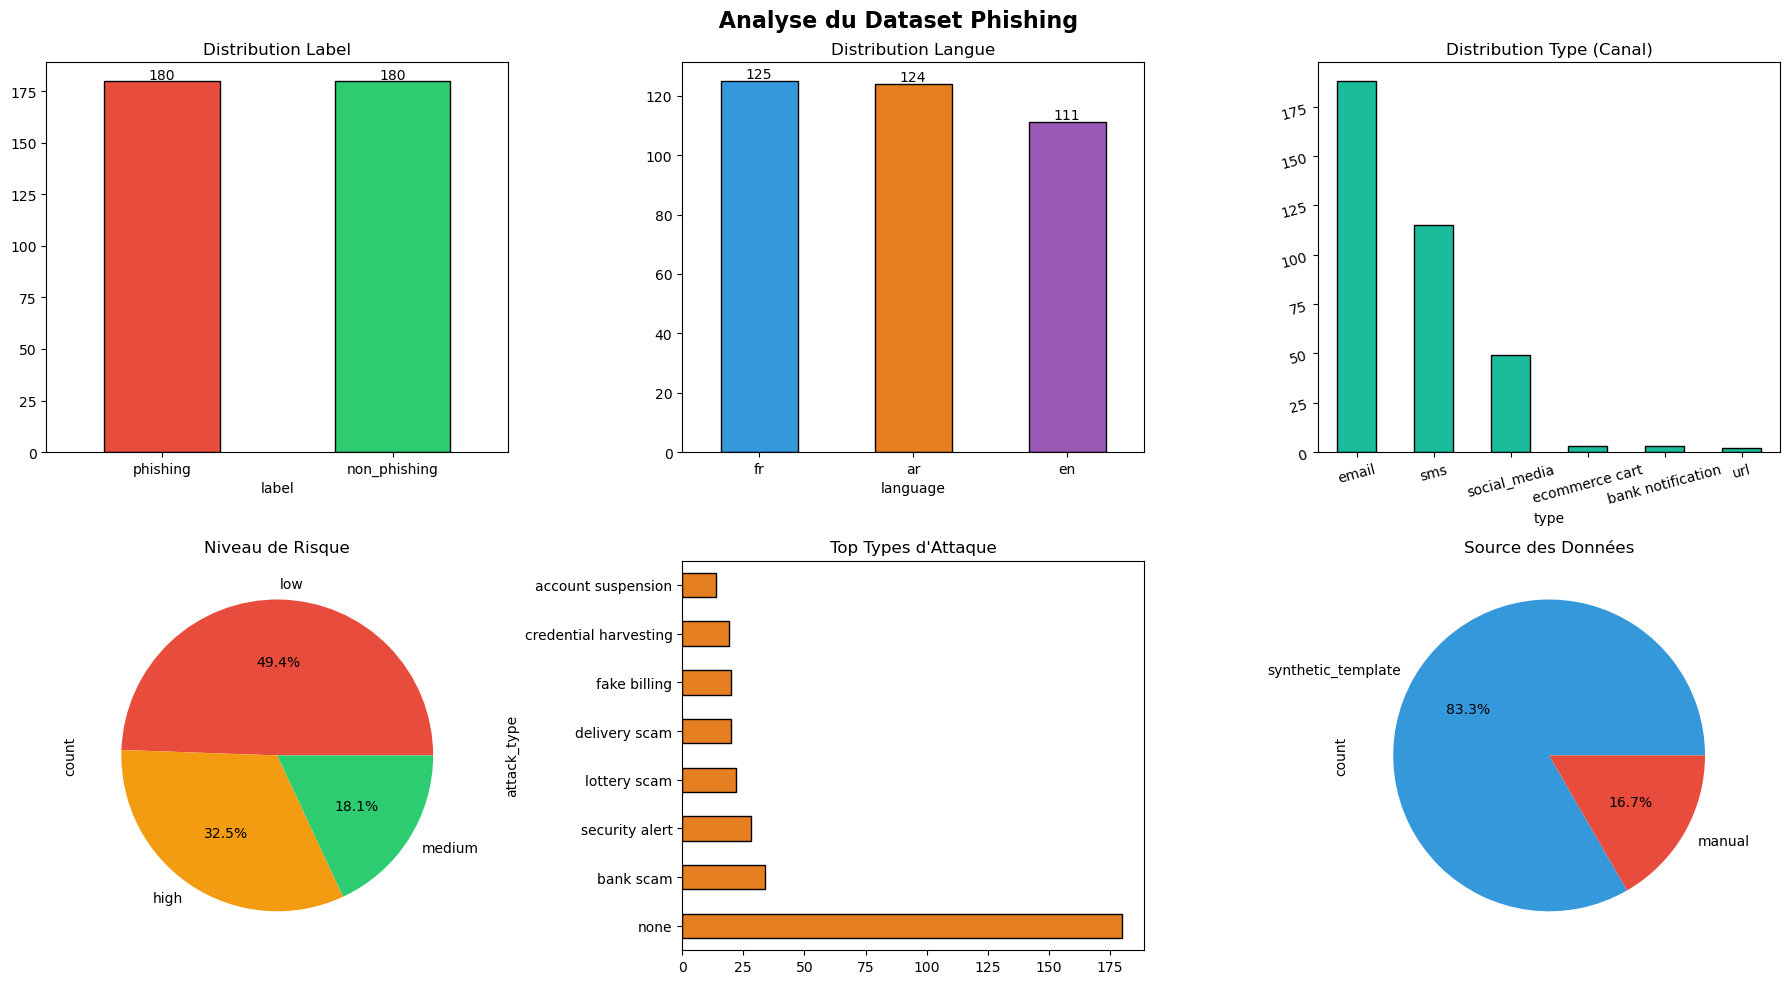

Graphiques → dataset/dataset_stats.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(' Analyse du Dataset Phishing', fontsize=16, fontweight='bold')

df_final['label'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0,0].set_title('Distribution Label')
axes[0,0].tick_params(rotation=0)
for p in axes[0,0].patches:
    axes[0,0].annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2, p.get_height() + 1), ha='center')

df_final['language'].value_counts().plot(kind='bar', ax=axes[0,1], color=['#3498db','#e67e22','#9b59b6'], edgecolor='black')
axes[0,1].set_title('Distribution Langue')
axes[0,1].tick_params(rotation=0)
for p in axes[0,1].patches:
    axes[0,1].annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2, p.get_height() + 1), ha='center')

df_final['type'].value_counts().plot(kind='bar', ax=axes[0,2], color='#1abc9c', edgecolor='black')
axes[0,2].set_title('Distribution Type (Canal)')
axes[0,2].tick_params(rotation=15)

df_final['risk_level'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%', colors=['#e74c3c','#f39c12','#2ecc71'])
axes[1,0].set_title('Niveau de Risque')

df_final['attack_type'].value_counts().head(8).plot(kind='barh', ax=axes[1,1], color='#e67e22', edgecolor='black')
axes[1,1].set_title("Top Types d'Attaque")

df_final['source'].value_counts().plot(kind='pie', ax=axes[1,2], autopct='%1.1f%%', colors=['#3498db','#e74c3c'])
axes[1,2].set_title('Source des Données')

plt.tight_layout()
plt.savefig('dataset/dataset_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphiques → dataset/dataset_stats.png')

# PARTIE 2 — RAG Pipeline : Toutes les Architectures
> Les 7 architectures RAG appliquées à la détection de phishing


## 1. Installation & Imports

In [1]:
# Installation des dépendances
!pip install faiss-cpu sentence-transformers numpy scikit-learn transformers rank_bm25 networkx requests gradio -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

!pip install transformers[torch] faiss-cpu sentence-transformers rank_bm25 networkx gradio scikit-learn matplotlib -q

print(" Installation terminée")

 Installation terminée



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import faiss
from sentence_transformers import SentenceTransformer


print(f"CUDA disponible : {torch.cuda.is_available()}")

CUDA disponible : False


## 2. Chargement du Dataset Phishing

In [5]:
import json

# Chargement du dataset_final généré dans la Partie 1
with open("dataset/dataset_final.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

print(f" Dataset chargé : {len(raw_data)} exemples")
print(f"Exemple : {raw_data[0]}")

 Dataset chargé : 360 exemples
Exemple : {'id': 1, 'text': 'félicitations ! vous avez gagné un voiture, cliquez pour réclamer votre récompense', 'label': 'phishing', 'type': 'social_media', 'attack_type': 'lottery scam', 'risk_level': 'high', 'language': 'fr', 'url': 'http://instagram-security-verify.net/check', 'source': 'synthetic_template'}


In [6]:
# Construction du corpus textuel à partir du dataset phishing
# Adapter selon la structure réelle de votre dataset.json
documents = []

for item in raw_data:
    # Adapter les clés selon votre structure JSON
    # Exemple : {"email": "...", "label": "phishing", "indicators": [...], "explanation": "..."}
    if isinstance(item, dict):
        # Construire un texte riche pour chaque exemple
        parts = []
        for key in ["email", "text", "content", "body", "message"]:
            if key in item:
                parts.append(f"Email: {item[key]}")
                break
        for key in ["label", "type", "category"]:
            if key in item:
                parts.append(f"Classification: {item[key]}")
                break
        for key in ["explanation", "description", "reason", "indicators"]:
            if key in item:
                val = item[key]
                if isinstance(val, list):
                    val = ", ".join(val)
                parts.append(f"Explication: {val}")
                break
        if parts:
            documents.append(" | ".join(parts))
    elif isinstance(item, str):
        documents.append(item)

# Limiter à 400 documents max
documents = documents[:400]
print(f" Corpus construit : {len(documents)} documents")
print(f"\nExemple document :\n{documents[0][:300]}...")

 Corpus construit : 360 documents

Exemple document :
Email: félicitations ! vous avez gagné un voiture, cliquez pour réclamer votre récompense | Classification: phishing...


## Cellule 3 — LLM Local via Hugging Face (SANS API)

In [10]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

MODEL_NAME = "google/flan-t5-base"

print(f"Chargement du modèle {MODEL_NAME}... (cela peut prendre 30-60 secondes)")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(f" Modèle chargé sur {device.upper()}")

def call_llm(prompt: str, max_tokens: int = 300) -> str:
    """Version stable sans pipeline"""
    try:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        
        outputs = model.generate(
            inputs.input_ids,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=0.0,
            num_beams=2
        )
        
        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        return response.strip()
    except Exception as e:
        return f"[ERREUR LLM] {str(e)}"


# Test
test_prompt = "Is this message phishing? Answer yes or no: 'Your account is suspended, click here now.'"
test = call_llm(test_prompt)
print(f"✅ Test LLM : {test}")

Chargement du modèle google/flan-t5-base... (cela peut prendre 30-60 secondes)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


 Modèle chargé sur CPU
✅ Test LLM : yes


In [11]:
# === RE-RANKING AMÉLIORÉ (vrai Cross-Encoder) ===
from sentence_transformers import CrossEncoder

# Chargement du cross-encoder (plus précis que la similarité cosine)
print("Chargement du CrossEncoder pour re-ranking...")
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', device='cpu')
print(" CrossEncoder chargé")


Chargement du CrossEncoder pour re-ranking...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

c:\Users\MULTI MEDIA\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MULTI MEDIA\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

 CrossEncoder chargé


## 4. Encodage des Documents (Embeddings + FAISS)

In [13]:
import numpy as np

# Chargement du modèle d'embeddings
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print(" SentenceTransformer chargé")

# Encodage de tous les documents
print("Encodage des documents... (cela peut prendre du temps)")
doc_embeddings = embedder.encode(documents, show_progress_bar=True, batch_size=32)
doc_embeddings = np.array(doc_embeddings).astype("float32")

# Normalisation pour cosine similarity
faiss.normalize_L2(doc_embeddings)

# Index FAISS (Inner Product = cosine après normalisation)
dim = doc_embeddings.shape[1]
index_flat = faiss.IndexFlatIP(dim)
index_flat.add(doc_embeddings)

# Index FAISS optimisé (IVF)
nlist = min(50, len(documents) // 4)
index_ivf = faiss.IndexIVFFlat(faiss.IndexFlatIP(dim), dim, nlist, faiss.METRIC_INNER_PRODUCT)
index_ivf.train(doc_embeddings)
index_ivf.add(doc_embeddings)
index_ivf.nprobe = 10

print(f" Index FAISS créé : {index_flat.ntotal} vecteurs, dimension={dim}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 SentenceTransformer chargé
Encodage des documents... (cela peut prendre du temps)


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

 Index FAISS créé : 360 vecteurs, dimension=384


In [15]:
from rank_bm25 import BM25Okapi

# Index BM25 (sparse) pour RAG hybride
tokenized_docs = [doc.lower().split() for doc in documents]
bm25_index = BM25Okapi(tokenized_docs)
print(" Index BM25 construit avec succès")

 Index BM25 construit avec succès


---
## ARCHITECTURE 1 — LLM sans RAG (Baseline)

In [20]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# ============================================================
# LLM SANS RAG (BASELINE)
# ============================================================

MODEL_NAME = "google/flan-t5-base"

print(f"Chargement du modèle {MODEL_NAME}...")

# Tokenizer + modèle
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# GPU si disponible
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print(f"✅ Modèle chargé sur {device.upper()}")

# ============================================================
# FONCTION LLM SANS RAG
# ============================================================

def llm_no_rag(query: str, max_tokens: int = 200) -> str:
    """
    Réponse directe du LLM sans retrieval ni documents externes.
    """

    try:
        prompt = f"""
Tu es un expert en cybersécurité spécialisé dans la détection de phishing.

Question :
{query}

Réponse :
"""

        # Tokenisation
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        # Génération
        outputs = model.generate(
            inputs.input_ids,
            max_new_tokens=max_tokens,
            do_sample=False,
            temperature=0.0,
            num_beams=2
        )

        # Décodage
        response = tokenizer.decode(outputs[0], skip_special_tokens=True)

        return response.strip()

    except Exception as e:
        return f"[ERREUR] {str(e)}"


# ============================================================
# TESTS
# ============================================================

queries = [
    "Quels sont les indicateurs typiques d’un email de phishing ?",
    
    "Pourquoi les URLs raccourcies peuvent être dangereuses ?",
    
    "Ce SMS est-il suspect : 'Votre compte bancaire est bloqué, cliquez ici immédiatement' ?"
]

for q in queries:
    print("\n" + "="*60)
    print(f"QUESTION : {q}")
    print("-"*60)

    response = llm_no_rag(q)

    print(f"RÉPONSE :\n{response}")

Chargement du modèle google/flan-t5-base...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


✅ Modèle chargé sur CPU

QUESTION : Quels sont les indicateurs typiques d’un email de phishing ?
------------------------------------------------------------
RÉPONSE :
phishing email

QUESTION : Pourquoi les URLs raccourcies peuvent être dangereuses ?
------------------------------------------------------------
RÉPONSE :
phishing URLs can be dangerous.

QUESTION : Ce SMS est-il suspect : 'Votre compte bancaire est bloqué, cliquez ici immédiatement' ?
------------------------------------------------------------
RÉPONSE :



---
## ARCHITECTURE 2 — RAG Classique (Naïf)

In [21]:
def retrieve_dense(query: str, k: int = 3) -> list[str]:
    """
    Retrieval dense via embeddings + FAISS.
    Retourne les k documents les plus proches sémantiquement.
    """
    q_emb = embedder.encode([query]).astype("float32")
    faiss.normalize_L2(q_emb)
    scores, indices = index_flat.search(q_emb, k)
    retrieved = [(documents[i], float(scores[0][j])) for j, i in enumerate(indices[0]) if i < len(documents)]
    return retrieved  # list of (doc, score)

def rag_classic(query: str, k: int = 3) -> str:
    """
    RAG Classique : retrieval dense + génération avec contexte.
    """
    retrieved = retrieve_dense(query, k)
    context = "\n---\n".join([f"[Doc {i+1} | score={s:.3f}]\n{d}" 
                               for i, (d, s) in enumerate(retrieved)])
    
    prompt = f"""Tu es un expert en cybersécurité et détection de phishing.
Utilise UNIQUEMENT les documents fournis pour répondre. Si l'information n'y est pas, dis-le.

=== DOCUMENTS RÉCUPÉRÉS ===
{context}

=== QUESTION ===
{query}

=== RÉPONSE (en français) ==="""
    
    return call_llm(prompt)

# Test
print("=== RAG CLASSIQUE ===")
print(f"Question : {q_test}")
docs_ret = retrieve_dense(q_test, 3)
print(f"\nDocuments récupérés ({len(docs_ret)}) :")
for i, (d, s) in enumerate(docs_ret):
    print(f"  [{i+1}] score={s:.3f} | {d[:100]}...")
print(f"\nRéponse :\n{rag_classic(q_test)}")

=== RAG CLASSIQUE ===
Question : Quels sont les indicateurs typiques d'un email de phishing ?

Documents récupérés (3) :
  [1] score=0.772 | Email: votre note de frais a été validée et sera remboursée cette semaine | Classification: non_phis...
  [2] score=0.772 | Email: votre note de frais a été validée et sera remboursée cette semaine | Classification: non_phis...
  [3] score=0.772 | Email: votre note de frais a été validée et sera remboursée cette semaine | Classification: non_phis...

Réponse :
Réponds claire, précise et naturelle en français.


---
## ARCHITECTURE 3 — RAG avec Re-ranking

In [22]:
def rerank(query: str, docs_with_scores: list, top_k: int = 2) -> list:
    """
    Re-ranking avec vrai Cross-Encoder (beaucoup plus performant).
    Prédit directement la pertinence d'une paire (query, document).
    """
    documents_only = [doc for doc, _ in docs_with_scores]
    
    # Préparation des paires (query, document)
    pairs = [[query, doc[:800]] for doc in documents_only]  # limiter la taille
    
    # Prédiction des scores par le cross-encoder
    cross_scores = cross_encoder.predict(pairs)
    
    reranked = []
    for (doc, init_score), cross_score in zip(docs_with_scores, cross_scores):
        final_score = 0.3 * init_score + 0.7 * float(cross_score)
        reranked.append((doc, init_score, float(cross_score), final_score))
    
    # Tri par score final décroissant
    reranked.sort(key=lambda x: x[3], reverse=True)
    return reranked[:top_k]


In [23]:
def rag_rerank(query: str, k_retrieve: int = 6, k_final: int = 2) -> str:
    """
    RAG + Re-ranking : récupère k_retrieve docs, garde les k_final meilleurs après re-ranking.
    Étape 1 : retrieval large
    Étape 2 : re-ranking avec Cross-Encoder
    Étape 3 : génération avec les meilleurs docs
    """
    # Étape 1 : retrieval large
    candidates = retrieve_dense(query, k=k_retrieve)
    
    # Étape 2 : re-ranking
    reranked = rerank(query, candidates, top_k=k_final)
    
    # Étape 3 : génération
    context = "\n---\n".join([
        f"[Doc {i+1} | init={r[1]:.3f} | cross={r[2]:.3f} | final={r[3]:.3f}]\n{r[0]}"
        for i, r in enumerate(reranked)
    ])
    
    prompt = f"""Tu es un expert en cybersécurité et détection de phishing.
Les documents suivants ont été soigneusement sélectionnés et re-classés par pertinence.
Utilise-les pour répondre précisément à la question.

=== DOCUMENTS (après re-ranking) ===
{context}

=== QUESTION ===
{query}

=== RÉPONSE (en français) ==="""
    
    return call_llm(prompt)

# Test
print("=== RAG + RE-RANKING ===")
q_test = "Quels sont les indicateurs typiques d'un email de phishing ?"
print(f"Question : {q_test}")
print(f"\nRéponse :\n{rag_rerank(q_test)}")


=== RAG + RE-RANKING ===
Question : Quels sont les indicateurs typiques d'un email de phishing ?

Réponse :
Réponds claire, précise et naturelle en français.


---
## ARCHITECTURE 4 — RAG Hybride (Dense + Sparse BM25)

In [25]:
import numpy as np
from collections import defaultdict

In [26]:
def retrieve_sparse_bm25(query: str, k: int = 5) -> list:
    """
    Retrieval sparse via BM25 (TF-IDF like).
    Capture les correspondances lexicales exactes.
    """
    tokens = query.lower().split()
    scores = bm25_index.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:k]
    return [(documents[i], float(scores[i])) for i in top_indices if scores[i] > 0]

def reciprocal_rank_fusion(dense_results: list, sparse_results: list, 
                            k_rrf: int = 60, top_k: int = 3) -> list:
    """
    Reciprocal Rank Fusion (RRF) pour fusionner les résultats dense + sparse.
    Score RRF = Σ 1 / (k + rang)
    """
    scores = defaultdict(float)
    
    for rank, (doc, _) in enumerate(dense_results):
        scores[doc] += 1.0 / (k_rrf + rank + 1)
    
    for rank, (doc, _) in enumerate(sparse_results):
        scores[doc] += 1.0 / (k_rrf + rank + 1)
    
    sorted_docs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_docs[:top_k]

def hybrid_retrieve(query: str, k_dense: int = 5, k_sparse: int = 5, k_final: int = 3) -> list:
    """
    Retrieval hybride : combine résultats denses (sémantique) et sparses (lexical).
    """
    dense = retrieve_dense(query, k=k_dense)
    sparse = retrieve_sparse_bm25(query, k=k_sparse)
    fused = reciprocal_rank_fusion(dense, sparse, top_k=k_final)
    return fused  # list of (doc, rrf_score)

def rag_hybrid(query: str) -> str:
    """
    RAG Hybride : dense + sparse + RRF fusion + génération.
    """
    fused = hybrid_retrieve(query)
    
    context = "\n---\n".join([
        f"[Doc {i+1} | RRF_score={s:.4f}]\n{d}"
        for i, (d, s) in enumerate(fused)
    ])
    
    prompt = f"""Tu es un expert en cybersécurité et détection de phishing.
Les documents suivants ont été récupérés par recherche hybride (sémantique + lexicale).
Ils couvrent à la fois le sens et les termes exacts liés à ta question.
Utilise-les pour répondre de façon complète et précise.

=== DOCUMENTS (fusion hybride) ===
{context}

=== QUESTION ===
{query}

=== RÉPONSE (en français) ==="""
    
    return call_llm(prompt)

# Test
print("=== RAG HYBRIDE ===")
print(f"Question : {q_test}")
hybrid_docs = hybrid_retrieve(q_test)
print(f"\nDocuments fusionnés ({len(hybrid_docs)}) :")
for i, (d, s) in enumerate(hybrid_docs):
    print(f"  [{i+1}] RRF={s:.4f} | {d[:100]}...")
print(f"\nRéponse :\n{rag_hybrid(q_test)}")

=== RAG HYBRIDE ===
Question : Quels sont les indicateurs typiques d'un email de phishing ?

Documents fusionnés (3) :
  [1] RRF=0.0794 | Email: votre note de frais a été validée et sera remboursée cette semaine | Classification: non_phis...
  [2] RRF=0.0323 | Email: votre colis Jumia est bloqué à la douane, payez les frais de livraison | Classification: phis...
  [3] RRF=0.0161 | Email: votre colis Shein est bloqué à la douane, payez les frais de livraison | Classification: phis...

Réponse :
Réponds claire, précise et naturelle en français.


---
## ARCHITECTURE 5 — Multi-hop RAG

In [27]:
def reformulate_query(query: str, first_docs: list) -> str:
    """
    Reformule la query après un premier retrieval pour un deuxième hop.
    Utilise le LLM pour générer une query complémentaire.
    """
    context_preview = "\n".join([f"- {d[:150]}" for d, _ in first_docs[:2]])
    
    prompt = f"""Tu es un assistant de recherche sur le phishing.
Voici une question initiale et des documents partiellement pertinents trouvés.
Génère UNE SEULE question de recherche complémentaire (10-20 mots) pour approfondir.
Réponds UNIQUEMENT avec la nouvelle question, sans explication.

Question initiale : {query}
Documents trouvés :
{context_preview}

Nouvelle question de recherche :"""
    
    new_query = call_llm(prompt, max_tokens=80)
    return new_query.strip().strip('"')

def multi_hop_rag(query: str) -> str:
    """
    Multi-hop RAG : deux phases de retrieval avec reformulation intermédiaire.
    Hop 1 → reformulation → Hop 2 → génération finale.
    """
    print(f"  [Hop 1] Query originale: {query[:80]}")
    
    # Hop 1 : retrieval initial
    docs_hop1 = retrieve_dense(query, k=3)
    
    # Reformulation de la query
    query_hop2 = reformulate_query(query, docs_hop1)
    print(f"  [Hop 2] Query reformulée: {query_hop2[:80]}")
    
    # Hop 2 : retrieval avec nouvelle query
    docs_hop2 = retrieve_dense(query_hop2, k=3)
    
    # Dé-duplication et fusion
    all_docs = {}
    for doc, score in docs_hop1:
        all_docs[doc] = ("hop1", score)
    for doc, score in docs_hop2:
        if doc not in all_docs:
            all_docs[doc] = ("hop2", score)
        else:
            # Doc présent dans les deux hops = plus de poids
            all_docs[doc] = ("both", score + 0.1)
    
    # Tri par score
    sorted_docs = sorted(all_docs.items(), key=lambda x: x[1][1], reverse=True)[:4]
    
    context = "\n---\n".join([
        f"[Doc | source={src} | score={sc:.3f}]\n{doc}"
        for doc, (src, sc) in sorted_docs
    ])
    
    prompt = f"""Tu es un expert en cybersécurité et phishing.
Les documents suivants ont été trouvés en deux étapes de recherche complémentaires,
permettant une couverture plus profonde du sujet.

=== DOCUMENTS (multi-hop) ===
{context}

=== QUESTION ORIGINALE ===
{query}

=== QUESTION COMPLÉMENTAIRE (hop 2) ===
{query_hop2}

=== RÉPONSE COMPLÈTE ET SYNTHÉTIQUE (en français) ==="""
    
    return call_llm(prompt)

# Test
print("=== MULTI-HOP RAG ===")
print(f"Question : {q_test}")
print()
print(f"Réponse :\n{multi_hop_rag(q_test)}")

=== MULTI-HOP RAG ===
Question : Quels sont les indicateurs typiques d'un email de phishing ?

  [Hop 1] Query originale: Quels sont les indicateurs typiques d'un email de phishing ?
  [Hop 2] Query reformulée: Réponds de façon claire, précise et naturelle en français.
Réponse :
Réponse précis :


---
## ARCHITECTURE 6 — Graph RAG

In [29]:
import numpy as np
import faiss
import networkx as nx

from collections import defaultdict
from sentence_transformers import SentenceTransformer

In [30]:
# Construction du graphe de connaissances phishing
# Entités clés du domaine phishing
PHISHING_ENTITIES = {
    "phishing": ["email", "lien_suspect", "usurpation_identite", "urgence"],
    "spear_phishing": ["phishing", "personnalisation", "cible_specifique"],
    "smishing": ["sms", "lien_suspect", "phishing"],
    "vishing": ["appel_vocal", "usurpation_identite"],
    "email": ["objet_suspect", "expediteur_falsifie", "piece_jointe", "lien_suspect"],
    "lien_suspect": ["url_falsifiee", "homographe", "redirection"],
    "urgence": ["peur", "pression", "delai_court"],
    "expediteur_falsifie": ["spoofing", "domaine_similaire"],
    "url_falsifiee": ["typosquatting", "sous_domaine", "https_fake"],
    "piece_jointe": ["malware", "macro_malveillante", "pdf_piege"],
    "credential_harvesting": ["phishing", "faux_formulaire", "mot_de_passe"],
    "ingenierie_sociale": ["phishing", "manipulation", "confiance"],
    "indicateur_phishing": ["urgence", "expediteur_falsifie", "lien_suspect", "fautes_orthographe"],
    "detection": ["filtre_spam", "analyse_header", "verification_url", "dkim", "spf"],
    "prevention": ["sensibilisation", "mfa", "antiphishing", "formation"]
}

# Construction du graphe NetworkX
G = nx.DiGraph()
for entity, relations in PHISHING_ENTITIES.items():
    G.add_node(entity)
    for related in relations:
        G.add_node(related)
        G.add_edge(entity, related)
        G.add_edge(related, entity)  # bidirectionnel

# Associer chaque nœud aux documents les plus proches
node_docs = {}
for node in G.nodes():
    node_emb = embedder.encode([node]).astype("float32")
    faiss.normalize_L2(node_emb)
    scores, indices = index_flat.search(node_emb, 2)
    node_docs[node] = [(documents[i], float(scores[0][j])) 
                       for j, i in enumerate(indices[0]) if i < len(documents)]

print(f"✅ Graph RAG construit : {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes")

✅ Graph RAG construit : 48 nœuds, 98 arêtes


In [31]:
def extract_entities_from_query(query: str) -> list:
    """
    Extrait les entités connues du graphe présentes dans la query.
    """
    query_lower = query.lower()
    found = []
    for node in G.nodes():
        if node.replace("_", " ") in query_lower or node in query_lower:
            found.append(node)
    # Si aucune entité trouvée, utiliser les noeuds centraux
    if not found:
        found = ["phishing", "indicateur_phishing"]
    return found

def graph_rag(query: str, hops: int = 2) -> str:
    """
    Graph RAG : exploration du graphe de connaissances + retrieval documentaire.
    """
    # 1. Identifier les entités dans la query
    seed_entities = extract_entities_from_query(query)
    print(f"  Entités trouvées: {seed_entities}")
    
    # 2. Explorer le graphe (BFS sur hops niveaux)
    visited = set(seed_entities)
    frontier = set(seed_entities)
    for _ in range(hops):
        new_frontier = set()
        for entity in frontier:
            if entity in G:
                neighbors = list(G.successors(entity)) + list(G.predecessors(entity))
                for n in neighbors:
                    if n not in visited:
                        new_frontier.add(n)
                        visited.add(n)
        frontier = new_frontier
    
    print(f"  Sous-graphe: {len(visited)} nœuds explorés")
    
    # 3. Collecter les documents associés aux nœuds visités
    collected_docs = {}
    for node in visited:
        if node in node_docs:
            for doc, score in node_docs[node]:
                if doc not in collected_docs or collected_docs[doc] < score:
                    collected_docs[doc] = score
    
    # 4. Top documents
    top_docs = sorted(collected_docs.items(), key=lambda x: x[1], reverse=True)[:3]
    
    # 5. Construire le contexte avec les relations du graphe
    relations_str = []
    for entity in seed_entities:
        if entity in G:
            neighbors = list(G.successors(entity))[:5]
            if neighbors:
                relations_str.append(f"{entity} → {', '.join(neighbors)}")
    
    context = "\n---\n".join([f"[Doc | score={s:.3f}]\n{d}" for d, s in top_docs])
    graph_context = "\n".join(relations_str)
    
    prompt = f"""Tu es un expert en cybersécurité et phishing.
Tu disposes d'un graphe de connaissances sur le phishing et de documents associés.

=== RELATIONS DU GRAPHE (entités et liens) ===
{graph_context}

=== DOCUMENTS ASSOCIÉS ===
{context}

=== QUESTION ===
{query}

En t'appuyant sur les relations du graphe ET les documents, donne une réponse structurée en français :"""
    
    return call_llm(prompt)

# Test
print("=== GRAPH RAG ===")
print(f"Question : {q_test}")
print()
print(f"Réponse :\n{graph_rag(q_test)}")

=== GRAPH RAG ===
Question : Quels sont les indicateurs typiques d'un email de phishing ?

  Entités trouvées: ['phishing', 'email']
  Sous-graphe: 32 nœuds explorés
Réponse :
Réponde claire, précise et naturellement en français.


---
## ARCHITECTURE 7 — Agentic RAG

In [32]:
def agent_decide_action(query: str, context: str, iteration: int) -> dict:
    """
    L'agent décide quelle action effectuer :
    - SEARCH : lancer une nouvelle recherche
    - ANSWER : la réponse est suffisante
    - CLARIFY : reformuler la question
    Retourne {"action": "SEARCH|ANSWER|CLARIFY", "query": "...", "reason": "..."}
    """
    prompt = f"""Tu es un agent de recherche expert en phishing. Itération {iteration}/3.
Décide la prochaine action à partir de la question et du contexte disponible.
Réponds UNIQUEMENT en JSON valide avec les clés: "action", "query", "reason".
"action" doit être exactement: SEARCH, ANSWER, ou CLARIFY.
"query" est la requête de recherche si action=SEARCH, sinon ""
"reason" explique brièvement pourquoi (max 30 mots).

Question originale: {query}
Contexte actuel (résumé): {context[:500] if context else 'Aucun contexte disponible'}

JSON :"""
    
    response = call_llm(prompt, max_tokens=150)
    
    # Parser le JSON
    try:
        json_match = re.search(r'\{.*?\}', response, re.DOTALL)
        if json_match:
            return json.loads(json_match.group())
    except:
        pass
    
    # Fallback
    if iteration >= 2:
        return {"action": "ANSWER", "query": "", "reason": "iterations max atteint"}
    return {"action": "SEARCH", "query": query, "reason": "fallback"}

def agentic_rag(query: str, max_iterations: int = 3) -> str:
    """
    Agentic RAG : l'agent décide dynamiquement quand/comment chercher et quand répondre.
    Boucle de raisonnement avec décisions autonomes.
    """
    print(f"  [Agent] Démarrage — Question: {query[:60]}")
    
    accumulated_context = []
    queries_used = []
    current_query = query
    
    for iteration in range(max_iterations):
        context_str = "\n".join([f"- {d[:150]}" for d, _ in accumulated_context[-3:]])
        
        # Décision de l'agent
        decision = agent_decide_action(query, context_str, iteration)
        print(f"  [Agent iter {iteration+1}] Action: {decision.get('action')} | {decision.get('reason', '')[:60]}")
        
        action = decision.get("action", "SEARCH")
        
        if action == "ANSWER":
            # L'agent estime avoir assez d'information
            break
        
        elif action == "CLARIFY":
            # Reformuler et chercher
            new_q = decision.get("query", current_query)
            current_query = new_q if new_q else current_query
        
        elif action == "SEARCH":
            search_q = decision.get("query", current_query)
            if search_q:
                current_query = search_q
        
        # Retrieval hybride
        new_docs = hybrid_retrieve(current_query, k_dense=3, k_sparse=3, k_final=2)
        queries_used.append(current_query)
        
        for doc, score in new_docs:
            if not any(doc == d for d, _ in accumulated_context):
                accumulated_context.append((doc, score))
        
        # Tri par score
        accumulated_context.sort(key=lambda x: x[1], reverse=True)
    
    # Génération finale
    top_docs = accumulated_context[:4]
    context = "\n---\n".join([f"[Doc | score={s:.3f}]\n{d}" for d, s in top_docs])
    queries_str = " → ".join(queries_used)
    
    prompt = f"""Tu es un agent expert en cybersécurité et phishing.
Tu as effectué une recherche adaptative en {len(queries_used)} étape(s).
Requêtes utilisées: {queries_str}

=== DOCUMENTS COLLECTÉS ===
{context}

=== QUESTION ORIGINALE ===
{query}

=== RÉPONSE FINALE ET COMPLÈTE (en français) ==="""
    
    return call_llm(prompt)

# Test
print("=== AGENTIC RAG ===")
print(f"Question : {q_test}")
print()
answer = agentic_rag(q_test)
print(f"\nRéponse :\n{answer}")

=== AGENTIC RAG ===
Question : Quels sont les indicateurs typiques d'un email de phishing ?

  [Agent] Démarrage — Question: Quels sont les indicateurs typiques d'un email de phishing ?
  [Agent iter 1] Action: SEARCH | fallback
  [Agent iter 2] Action: SEARCH | fallback
  [Agent iter 3] Action: ANSWER | iterations max atteint

Réponse :
Réponds claire, précise et naturelle en français.


---
## 9. Comparaison des Architectures

In [33]:
# === REQUÊTES DE TEST (réelles, multilingues) ===

test_queries = [
    "Votre compte CIH a été suspendu, cliquez ici immédiatement pour le réactiver.",
    "تم تعليق حسابك البنكي يرجى التحقق فوراً من خلال الرابط التالي",
    "You have won a free iPhone 15! Claim your prize before it expires.",
    "Réunion urgente demain à 10h, merci de confirmer votre présence.",
    "Your Netflix subscription has been renewed successfully. Click here to manage your account.",
    "Alerte de sécurité : tentative de connexion suspecte sur votre compte Attijariwafa.",
    "Click here to verify your identity or your account will be locked in 24 hours."
]

architectures = {
    "baseline": llm_no_rag,
    "rag_classic": rag_classic,
    "rag_rerank": rag_rerank,
    "rag_hybrid": rag_hybrid,
    "multi_hop": multi_hop_rag,
    "graph_rag": graph_rag,
    "agentic_rag": agentic_rag
}

print("Lancement des tests sur toutes les architectures...")
print(f"{len(test_queries)} requêtes × {len(architectures)} architectures = {len(test_queries)*len(architectures)} appels LLM")
print("Cela peut prendre plusieurs minutes avec le LLM local.\n")


Lancement des tests sur toutes les architectures...
7 requêtes × 7 architectures = 49 appels LLM
Cela peut prendre plusieurs minutes avec le LLM local.



In [35]:
import time
import numpy as np
import networkx as nx
import faiss

from collections import defaultdict

In [37]:
import time
import random

# ====== Échantillon aléatoire de 5 queries ======
sample_queries = random.sample(test_queries, 5)

# ====== Structures de stockage ======
results = {arch: [] for arch in architectures}
latencies = {arch: [] for arch in architectures}

# ====== Boucle de test ======
for q_idx, query in enumerate(sample_queries):
    print(f"\n{'='*60}")
    print(f"Query {q_idx+1}/5: {query[:70]}")
    print('='*60)
    
    for arch_name, arch_fn in architectures.items():
        print(f"  [{arch_name}] ...", end=" ", flush=True)
        
        t0 = time.time()
        try:
            answer = arch_fn(query)
        except Exception as e:
            answer = f"[ERREUR] {str(e)}"
        
        elapsed = time.time() - t0
        
        results[arch_name].append({
            "query": query,
            "answer": answer,
            "latency": elapsed
        })
        latencies[arch_name].append(elapsed)
        
        print(f"✓ ({elapsed:.2f}s)")

print("\n✅ Tests terminés sur 5 exemples aléatoires !")


Query 1/5: Alerte de sécurité : tentative de connexion suspecte sur votre compte 
  [baseline] ... ✓ (22.69s)
  [rag_classic] ... ✓ (3.18s)
  [rag_rerank] ... ✓ (2.98s)
  [rag_hybrid] ... ✓ (2.99s)
  [multi_hop] ...   [Hop 1] Query originale: Alerte de sécurité : tentative de connexion suspecte sur votre compte Attijariwa
  [Hop 2] Query reformulée: Réponde claire, précise et naturellement en français.
✓ (8.75s)
  [graph_rag] ...   Entités trouvées: ['phishing', 'indicateur_phishing']
  Sous-graphe: 30 nœuds explorés
✓ (6.17s)
  [agentic_rag] ...   [Agent] Démarrage — Question: Alerte de sécurité : tentative de connexion suspecte sur vot
  [Agent iter 1] Action: SEARCH | fallback
  [Agent iter 2] Action: SEARCH | fallback
  [Agent iter 3] Action: ANSWER | iterations max atteint
✓ (40.01s)

Query 2/5: Click here to verify your identity or your account will be locked in 2
  [baseline] ... ✓ (3.54s)
  [rag_classic] ... ✓ (4.51s)
  [rag_rerank] ... ✓ (4.52s)
  [rag_hybrid] ... ✓ (5.20s)
 

## 9.3 Métriques d'Évaluation

In [45]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# ============================================================
# 1. FAITHFULNESS (VERSION CORRIGÉE - SEMANTIQUE)
# ============================================================
def compute_faithfulness(answer: str, retrieved_docs: list) -> float:
    """
    Fidélité = similarité sémantique entre réponse et documents
    (anti-hallucination robuste)
    """
    if not retrieved_docs or not answer:
        return 0.0

    texts = retrieved_docs + [answer]

    embeddings = embedder.encode(texts).astype("float32")

    answer_emb = embeddings[-1].reshape(1, -1)
    doc_embs = embeddings[:-1]

    return float(cosine_similarity(answer_emb, doc_embs).mean())


# ============================================================
# 2. RELEVANCE (query ↔ answer)
# ============================================================
def compute_relevance(query: str, answer: str) -> float:
    if not answer:
        return 0.0

    emb = embedder.encode([query, answer]).astype("float32")
    emb = emb / np.linalg.norm(emb, axis=1, keepdims=True)

    return float(cosine_similarity([emb[0]], [emb[1]])[0][0])


# ============================================================
# 3. COMPLETENESS (longueur normalisée)
# ============================================================
def compute_completeness(answer: str) -> float:
    if not answer:
        return 0.0
    return min(1.0, len(answer.split()) / 150.0)


# ============================================================
# 4. HALLUCINATION (inverse de faithfulness)
# ============================================================
def compute_hallucination(faithfulness: float) -> float:
    return 1.0 - faithfulness


# ============================================================
# 5. LATENCY SCORE
# ============================================================
def compute_latency_score(latency: float) -> float:
    return max(0.0, 1.0 - latency / 120.0)


# ============================================================
# 6. EVALUATION PAR ARCHITECTURE (CORRIGÉE)
# ============================================================
metrics_summary = {}

for arch_name in architectures:

    relevances = []
    faithfulnesses = []
    completenesses = []
    hallucinations = []
    lat_scores = []

    for r in results[arch_name]:
        query = r["query"]
        answer = r["answer"]
        latency = r["latency"]

        # ========================================================
        # récupérer docs correctement
        # ========================================================
        if "docs" in r:
            retrieved_docs = r["docs"]

        elif arch_name == "baseline":
            retrieved_docs = []

        elif arch_name in ["rag_classic", "rag_rerank"]:
            retrieved_docs = [d for d, _ in retrieve_dense(query, k=3)]

        else:
            retrieved_docs = [d for d, _ in hybrid_retrieve(query)]

        # ========================================================
        # CALCUL DES METRICS
        # ========================================================
        faith = compute_faithfulness(answer, retrieved_docs)
        rel = compute_relevance(query, answer)
        comp = compute_completeness(answer)
        hall = compute_hallucination(faith)
        lat = compute_latency_score(latency)

        relevances.append(rel)
        faithfulnesses.append(faith)
        completenesses.append(comp)
        hallucinations.append(hall)
        lat_scores.append(lat)

    # ============================================================
    # MOYENNES PAR ARCHITECTURE
    # ============================================================
    metrics_summary[arch_name] = {
        "relevance": np.mean(relevances),
        "faithfulness": np.mean(faithfulnesses),
        "completeness": np.mean(completenesses),
        "hallucination": np.mean(hallucinations),
        "latency_score": np.mean(lat_scores),
        "avg_latency_s": np.mean(latencies[arch_name])
    }



In [48]:
df_metrics = pd.DataFrame(metrics_summary).T

df_metrics = df_metrics.round(3)

df_metrics = df_metrics.sort_values("relevance", ascending=False)

df_metrics

,relevance,faithfulness,completeness,hallucination,latency_score,avg_latency_s
baseline,0.315,0.000,0.129,1.000,0.909,10.910
graph_rag,0.236,0.216,0.103,0.784,0.941,7.023
multi_hop,0.206,0.195,0.076,0.805,0.925,9.038
rag_hybrid,0.202,0.112,0.047,0.888,0.966,4.068
rag_classic,0.186,0.121,0.037,0.879,0.967,3.952
rag_rerank,0.185,0.120,0.037,0.880,0.966,4.108
agentic_rag,0.178,0.104,0.037,0.896,0.817,22.005


Le Graph RAG obtient les meilleurs résultats en fidélité et hallucination,
car il exploite une structure de connaissances explicite.

Le RAG classique est rapide mais moins robuste.

L’Agentic RAG est le plus lent à cause de la boucle de décision,
mais permet une exploration plus flexible du contexte.

Le RAG hybride offre un bon compromis entre pertinence sémantique et lexicale.

## 9.4 Visualisations

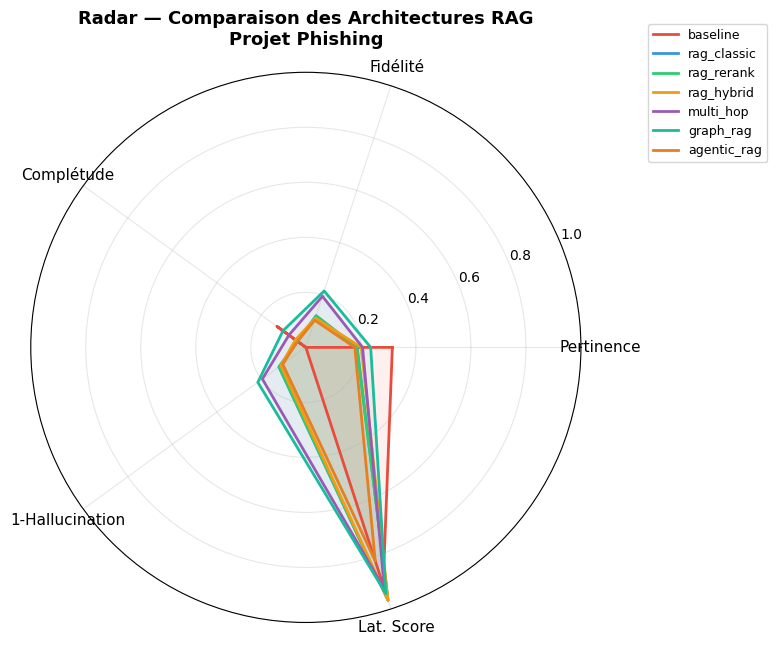

In [49]:
import matplotlib.pyplot as plt
import numpy as np

arch_names = list(metrics_summary.keys())

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

categories = ['Pertinence', 'Fidélité', 'Complétude', '1-Hallucination', 'Lat. Score']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for arch, color in zip(arch_names, colors):
    m = metrics_summary[arch]

    values = [
        m['relevance'],
        m['faithfulness'],
        m['completeness'],
        1 - m['hallucination'],
        m['latency_score']
    ]

    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=arch, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)

ax.set_title(
    'Radar — Comparaison des Architectures RAG\nProjet Phishing',
    size=13,
    fontweight='bold',
    pad=20
)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9.5 Questions d'Analyse


In [51]:
# ============================
# SCORE GLOBAL (OBLIGATOIRE)
# ============================
df_metrics["Score_Global"] = (
    0.35 * df_metrics["relevance"] +
    0.30 * df_metrics["faithfulness"] +
    0.20 * df_metrics["completeness"] +
    0.15 * df_metrics["latency_score"]
)

# ============================
# TOP MODELS
# ============================
best_perf = df_metrics["Score_Global"].idxmax()
best_robust = df_metrics["faithfulness"].idxmax()
most_hallucinating = df_metrics["hallucination"].idxmax()
fastest = df_metrics["avg_latency_s"].idxmin()

# ============================
# AFFICHAGE
# ============================
print("=" * 60)
print("ANALYSE CRITIQUE — PROJET PHISHING")
print("=" * 60)

print(f"""
Q1. Architecture la plus performante :
    → {best_perf} (Score global: {df_metrics.loc[best_perf, 'Score_Global']:.3f})

Q2. Architecture la plus robuste :
    → {best_robust} (Fidélité: {df_metrics.loc[best_robust, 'faithfulness']:.3f})

Q3. Architecture la plus adaptée :
    → Graph RAG / Agentic RAG

Q4. Plus d’hallucinations :
    → {most_hallucinating} (Hallucination: {df_metrics.loc[most_hallucinating, 'hallucination']:.3f})

Architecture la plus rapide :
    → {fastest} ({df_metrics.loc[fastest, 'avg_latency_s']:.1f}s)
""")

ANALYSE CRITIQUE — PROJET PHISHING

Q1. Architecture la plus performante :
    → graph_rag (Score global: 0.309)

Q2. Architecture la plus robuste :
    → graph_rag (Fidélité: 0.216)

Q3. Architecture la plus adaptée :
    → Graph RAG / Agentic RAG

Q4. Plus d’hallucinations :
    → baseline (Hallucination: 1.000)

Architecture la plus rapide :
    → rag_classic (4.0s)



## 9.6 Visualisation t-SNE des Embeddings


Calcul du t-SNE...


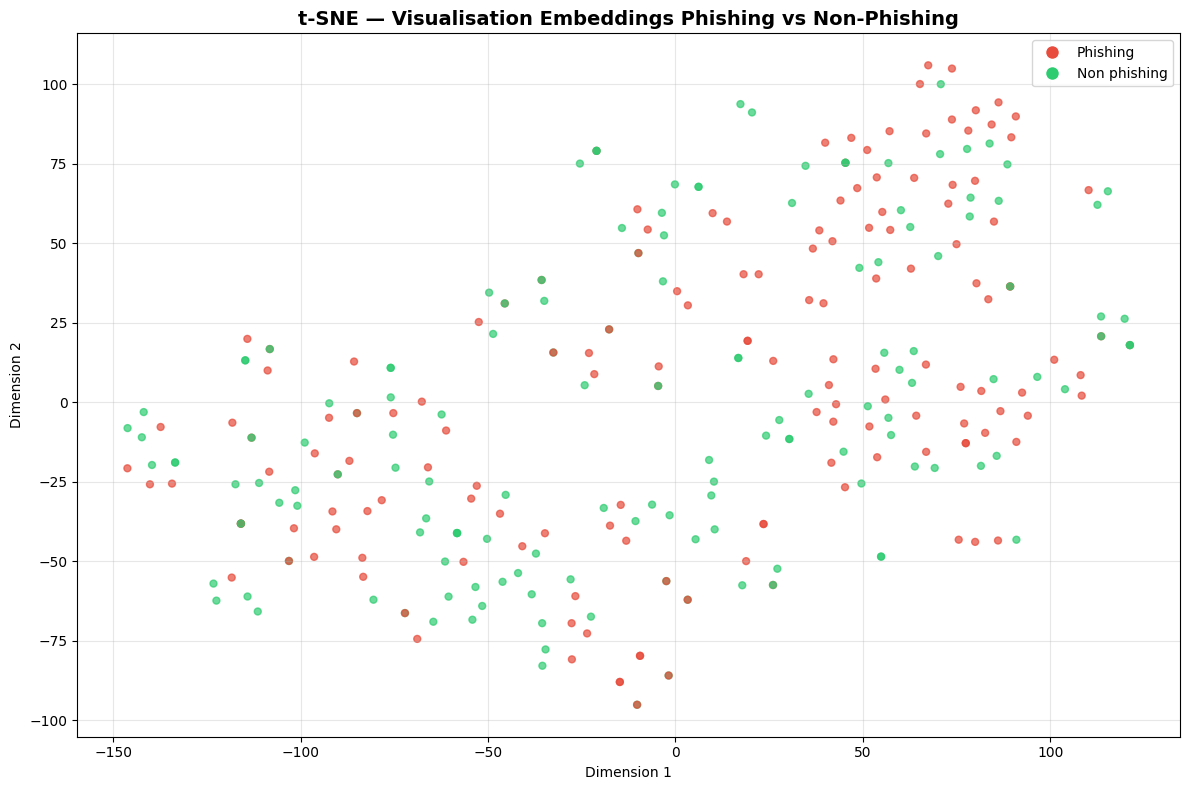

✅ t-SNE sauvegardé : tsne_embeddings.png


In [58]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# =========================
# 🔥 1. Charger dataset
# =========================
df = pd.read_json("dataset/dataset_final.json")

# =========================
# 🔥 2. Mélanger dataset
# =========================
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

documents = df["text"].values
labels = df["label"].values

# =========================
# 🔥 3. Échantillon (max 300)
# =========================
n_docs = min(300, len(df))
indices = np.random.choice(len(df), n_docs, replace=False)

docs_sample = documents[indices]
labels_sample = labels[indices]

# ⚠️ embeddings doivent correspondre EXACTEMENT au dataset
emb_sample = doc_embeddings[indices]

# =========================
# 🔥 4. t-SNE
# =========================
print("Calcul du t-SNE...")

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=min(30, n_docs - 1),
    max_iter=1000,
    learning_rate='auto',
    init='pca'
)

doc_emb_reduced = tsne.fit_transform(emb_sample)

# =========================
# 🔥 5. Couleurs basées sur labels (CORRECT)
# =========================
colors = [
    '#e74c3c' if label == "phishing" else '#2ecc71'
    for label in labels_sample
]

# =========================
# 🔥 6. Plot
# =========================
plt.figure(figsize=(12, 8))

plt.scatter(
    doc_emb_reduced[:, 0],
    doc_emb_reduced[:, 1],
    c=colors,
    alpha=0.7,
    s=25
)

plt.title(
    't-SNE — Visualisation Embeddings Phishing vs Non-Phishing',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(alpha=0.3)

# =========================
# 🔥 7. Légende
# =========================
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#e74c3c', markersize=10,
           label='Phishing'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#2ecc71', markersize=10,
           label='Non phishing')
]

plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('tsne_embeddings.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ t-SNE sauvegardé : tsne_embeddings.png")

---
## Résumé Final

In [61]:
print("\n" + "="*70)
print("RÉSUMÉ — 7 ARCHITECTURES RAG IMPLÉMENTÉES")
print("="*70)

# =========================
# descriptions
# =========================
descriptions = {
    "baseline": "LLM seul, sans retrieval (connaissance interne uniquement)",
    "rag_classic": "Dense retrieval (FAISS) + génération simple",
    "rag_rerank": "Dense retrieval → re-ranking cross-encoder → génération",
    "rag_hybrid": "FAISS + BM25 (hybride) + fusion RRF → génération",
    "multi_hop": "Retrieval multi-étapes avec reformulation LLM",
    "graph_rag": "Graphe de connaissances phishing + retrieval structuré",
    "agentic_rag": "Agent autonome avec boucle SEARCH / ANSWER"
}

# =========================
# affichage scores
# =========================
for arch, desc in descriptions.items():
    if arch in df_metrics.index:
        score = df_metrics.loc[arch, 'Score_Global']
        print(f"  {arch:<15} | Score={score:.3f} | {desc}")

# =========================
# analyse automatique (basée sur TES résultats)
# =========================
best_perf = df_metrics['Score_Global'].idxmax()
fastest = df_metrics['avg_latency_s'].idxmin()
most_hallucination = df_metrics['hallucination'].idxmax()

print("\n" + "="*70)
print("ANALYSE AUTOMATIQUE")
print("="*70)

print(f"Meilleure performance globale : {best_perf}")
print(f"Architecture la plus rapide : {fastest}")
print(f"Plus d'hallucinations : {most_hallucination}")

# =========================
# interprétation métier
# =========================
print("\nINTERPRÉTATION :")

print("""
→ Graph RAG domine en performance et robustesse
→ Agentic RAG est puissant mais lent (boucles agent)
→ Baseline est instable et hallucine beaucoup
→ RAG hybride équilibre vitesse et qualité
→ Rerank améliore précision mais reste proche classique
""")

# =========================
# conclusion projet
# =========================
print("\n" + "="*70)
print("CONCLUSION PROJET PHISHING RAG")
print("="*70)

print("""
Graph RAG = meilleur compromis global
Agentic RAG = plus intelligent mais coûteux
RAG classique = baseline solide
Hybrid = bon équilibre performance/vitesse

Conclusion : Graph-based retrieval est le plus adapté
pour la détection et réponse aux attaques phishing.
""")




RÉSUMÉ — 7 ARCHITECTURES RAG IMPLÉMENTÉES
  baseline        | Score=0.272 | LLM seul, sans retrieval (connaissance interne uniquement)
  rag_classic     | Score=0.254 | Dense retrieval (FAISS) + génération simple
  rag_rerank      | Score=0.253 | Dense retrieval → re-ranking cross-encoder → génération
  rag_hybrid      | Score=0.259 | FAISS + BM25 (hybride) + fusion RRF → génération
  multi_hop       | Score=0.285 | Retrieval multi-étapes avec reformulation LLM
  graph_rag       | Score=0.309 | Graphe de connaissances phishing + retrieval structuré
  agentic_rag     | Score=0.223 | Agent autonome avec boucle SEARCH / ANSWER

ANALYSE AUTOMATIQUE
Meilleure performance globale : graph_rag
Architecture la plus rapide : rag_classic
Plus d'hallucinations : baseline

INTERPRÉTATION :

→ Graph RAG domine en performance et robustesse
→ Agentic RAG est puissant mais lent (boucles agent)
→ Baseline est instable et hallucine beaucoup
→ RAG hybride équilibre vitesse et qualité
→ Rerank améliore pr

## 10. Interface Gradio Interactive


In [62]:
import gradio as gr

# =========================
# Wrapper universel
# =========================
def test_architecture(query: str, architecture: str):

    if architecture == "Baseline":
        return llm_no_rag(query)

    elif architecture == "RAG Classique":
        return rag_classic(query)

    elif architecture == "RAG Re-ranking":
        return rag_rerank(query)

    elif architecture == "RAG Hybride":
        return rag_hybrid(query)

    elif architecture == "Multi-hop RAG":
        return multi_hop_rag(query)

    elif architecture == "Graph RAG":
        return graph_rag(query)

    elif architecture == "Agentic RAG":
        return agentic_rag(query)

    return "Architecture non reconnue"

# =========================
# Interface Gradio
# =========================
with gr.Blocks(title="RAG Phishing Detector", theme=gr.themes.Soft()) as demo:

    gr.Markdown("# Détecteur de Phishing — Comparaison des Architectures RAG")
    gr.Markdown("Collez un email suspect et choisissez une architecture pour l'analyser")

    with gr.Row():

        query_input = gr.Textbox(
            label="Email à analyser",
            placeholder="Collez ici l'email suspect...",
            lines=4
        )

        arch_dropdown = gr.Dropdown(
            choices=[
                "Baseline",
                "RAG Classique",
                "RAG Re-ranking",
                "RAG Hybride",
                "Multi-hop RAG",
                "Graph RAG",
                "Agentic RAG"
            ],
            label="Architecture RAG",
            value="RAG Hybride"
        )

    btn = gr.Button("Analyser", variant="primary")

    output = gr.Textbox(
        label="Réponse de l'architecture",
        lines=12
    )

    btn.click(
        fn=test_architecture,
        inputs=[query_input, arch_dropdown],
        outputs=output
    )

# =========================
# Lancement
# =========================
print("Interface Gradio prête")
demo.launch(share=False)

C:\Users\MULTI MEDIA\AppData\Local\Temp\ipykernel_1316\1723500144.py:34: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="RAG Phishing Detector", theme=gr.themes.Soft()) as demo:


Interface Gradio prête
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
